In [1]:
import pyccl as ccl
import numpy as np
import matplotlib.pyplot as plt
from itertools import pairwise

import sys
sys.path.append('../')
from src import load_config, fisher_matrix, redshift_distributions, names_to_latex

## Load configuration

In [2]:
config = load_config('../configs/config_IA_bias.yaml')

## Setup and compute the Fisher matrix

In [3]:
print(f'Running fisher analysis for {config.name}.')
# Load the cosmology
ccl_cosmo_params = dict(zip(config.cosmology.keys(), config.cosmology.values()))
if 'Omega_m' in ccl_cosmo_params.keys():
    ccl_cosmo_params['Omega_c'] = ccl_cosmo_params['Omega_m'] - ccl_cosmo_params['Omega_b']
    ccl_cosmo_params.pop('Omega_m')
cosmo = ccl.Cosmology(**ccl_cosmo_params,
                      matter_power_spectrum='camb',
                      extra_parameters = {"camb": config.baryons_dict})

# ell binning setup
ell_bins = np.geomspace(config.ell_binning.cosmic_shear.bin_start,
                            config.ell_binning.cosmic_shear.bin_end,
                            config.ell_binning.cosmic_shear.N_bins)
ell_bins = ell_bins[
    (ell_bins >= config.ell_binning.cosmic_shear.ell_min) &
    (ell_bins <= config.ell_binning.cosmic_shear.ell_max)
    ].astype(int)
ell_arr = np.array([(a + b) / 2 for a, b in pairwise(ell_bins)]).astype(int)
Delta_ell = np.array([b - a for a, b in pairwise(ell_bins)])

# Or your own binning here
#ell_arr = np.arange(50, 1000)
#Delta_ell = None

# Define the forecasting setup
sigma_e = config.forecast.e_rms  # e-RMS for shape noise.
N_z_bins = config.redshift_distributions.sources.N_z_bins  # Number of z-bins.
z_arr = np.linspace(config.forecast.z_min, config.forecast.z_max,
                    config.forecast.N_z_values)
nz_arr, zbin_edges = (
    redshift_distributions.get_redshift_distributions(
        z_arr, N_z_bins,
        config.redshift_distributions.sources.z0,
        config.redshift_distributions.sources.a,
        config.redshift_distributions.sources.sigma_z))
# Galaxy number density, if not wanted to be from LSST Y1/Y10
#config['redshift_distributions']['sources']['nbar'] = 5./(4.*np.pi/(41253.0*60.0*60.0))

# Define the fisher matrix setup
cosmo_params = {'name': list(config.cosmology.keys()),
                'fiducial': list(config.cosmology.values()),
                'shift': [config.derivatives.step_size[x] for x in list(config.cosmology.keys())],
                'latex': [names_to_latex(x) for x in config.cosmology.keys()]}
astro_params = {'name': list(config.IA.keys())+list(config.baryons.keys()),
                'fiducial': list(config.IA.values())+list(config.baryons.values()),
                'shift': [config.derivatives.step_size[x] for x in list(config.IA.keys())+list(config.baryons.keys())],
                'latex': [names_to_latex(x) for x in list(config.IA.keys())+list(config.baryons.keys())]}
redshift_params = {'name': [f'dz{i+1}' for i in range(N_z_bins)],
                   'fiducial': [0.] * N_z_bins,
                   'shift': [config.derivatives.step_size.delta_z] * N_z_bins,
                   'latex': ['$\Delta z_{%i}$' % (i + 1) for i in range(N_z_bins)]}

# Compute the fisher matrix
print(f'Computing fisher matrix.')
fm = fisher_matrix(cosmo=cosmo, z=z_arr, dndz=nz_arr, ell=ell_arr,
                   sigma_e=sigma_e,
                   n_bar=config.redshift_distributions.sources.nbar,
                   fsky=config.forecast.fsky, Delta_ell=Delta_ell,
                   n_points=config.derivatives.stencil_points, cosmo_params=cosmo_params,
                   astro_params=astro_params, redshift_params=redshift_params)
# Add Gaussian photo-z priors
mean_z = np.trapz(nz_arr * z_arr, z_arr)
scale_z = config.redshift_distributions.sources.sigma_delta_z*(1+mean_z)
fm.add_prior(redshift_params['name'], scale_z)

Running fisher analysis for IA.
Computing fisher matrix.


In [4]:
# Print fisher matrix for validation
fm.fisher_matrix

array([[ 3.47895065e+06,  2.48028842e+06, -1.68349386e+05,
        -5.44168376e+04],
       [ 2.48028842e+06,  1.78923452e+06, -1.21611730e+05,
        -3.31825891e+04],
       [-1.68349386e+05, -1.21611730e+05,  8.98063149e+03,
         1.63325968e+03],
       [-5.44168376e+04, -3.31825891e+04,  1.63325968e+03,
         4.64909049e+03]])

## Fisher bias 
#### Compute the Fisher matrix without IA

In [5]:
'''cosmo_nob = ccl.Cosmology(Omega_c=config.cosmology.Omega_m-config.cosmology.Omega_b,
                      Omega_b=config.cosmology.Omega_b,
                      h=config.cosmology.h,
                      sigma8=config.cosmology.sigma8,
                      n_s=config.cosmology.n_s,
                      w0=config.cosmology.w0,
                      wa=config.cosmology.wa,
                      matter_power_spectrum='camb',
                          )#extra_parameters = {"camb": config.baryons_dict})'''

fm_no_AIA = fisher_matrix(cosmo=cosmo, z=z_arr, dndz=nz_arr, ell=ell_arr,
                          sigma_e=sigma_e,
                          n_bar=config.redshift_distributions.sources.nbar,
                          fsky=config.forecast.fsky, Delta_ell=Delta_ell,
                          n_points=config.derivatives.stencil_points,
                          cosmo_params=cosmo_params, redshift_params=redshift_params)
fm_no_AIA.add_prior(redshift_params['name'], scale_z)

#### Get the systematics $C_\ell$.

In [6]:
C_ell_sys = dict()
for key in fm.C_ell.keys():
    C_ell_sys[key] = fm.C_ell[key]-fm_no_AIA.C_ell[key]

#### Obtain the Fisher bias, using the assumed model (without IA).

In [7]:
N_params = fm_no_AIA.d_C_ell.shape[1]

bias = np.zeros(N_params)
for l in range(fm_no_AIA.data_covariance.shape[0]):
    C_ell_sys_at_ell = np.array(list(C_ell_sys.values()))[:,l]
    invcov = np.linalg.inv(fm_no_AIA.data_covariance[l])
    bias += (C_ell_sys_at_ell.dot(invcov)).dot(fm_no_AIA.d_C_ell[l].T)
bias = fm_no_AIA.covariance.dot(bias)

In [8]:
bias

array([-0.01000703,  0.01026225, -0.0397388 ])

## Compute the bias assuming a $\delta A_\mathrm{IA}$
Compute the expected bias
$$
(\delta\Omega_m, \delta\sigma_8) = (F_{\theta\theta})^{-1}\,\left(F_{\Omega_m,A_\mathrm{IA}},F_{\sigma_8,A_\mathrm{IA}}\right)^\mathrm{T}\,\delta A_\mathrm{IA}
$$
where the fisher matrix $F_{\theta\theta}$ is the matrix by fixing the systematics parameters and $F_{\Omega_m,A_\mathrm{IA}}$ is the element in the fisher matrix corresponding to $\Omega_m$ and $A_\mathrm{IA}$. 

In [9]:
f_Om_AIA = fm['Omega_m', 'A_IA'][0,1]
f_sig8_AIA = fm['sigma8', 'A_IA'][0,1]
f_cov_Om_sig8_marginalised = fm.marginalised_covariance(['Omega_m', 'sigma8'])  # Not used
f_cov_Om_sig8_fixed = np.linalg.inv(fm['Omega_m', 'sigma8'])  # If varying more cosmological parameters, they can be added further in the list.

In [10]:
delta_Om, delta_sig8 = f_cov_Om_sig8_fixed.dot(np.array([f_Om_AIA, f_sig8_AIA]))*fm.A_IA
print(delta_Om, delta_sig8)

-0.010340875864539212 0.013407535443825636


### Plot the bias:

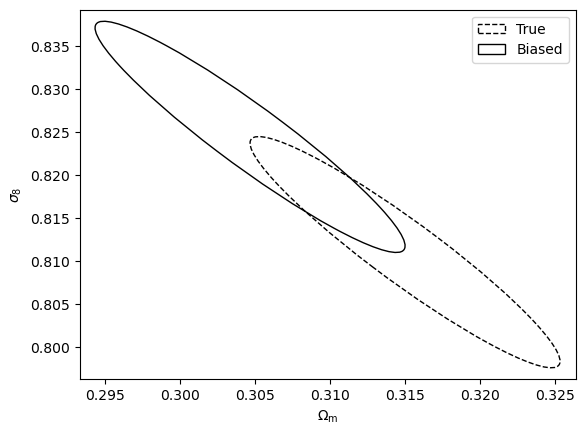

In [11]:
fig, ax = plt.subplots()

ax, xlim, ylim, mu, latex = fm.draw_covariance_ellipse(ax, ['Omega_m', 'sigma8'], mu=None, CL=0.68, color='k', fill=False, ls='--', label='True')

biased_center = np.array([fm.fiducial_parameters[0]+delta_Om, fm.fiducial_parameters[1]+delta_sig8])
ax, xlim_b, ylim_b, mu_b, latex_b = fm.draw_covariance_ellipse(ax, ['Omega_m', 'sigma8'], mu=biased_center, CL=0.68, color='k', fill=False, ls='-', label='Biased')

ax.set_xlim([min(mu[0]-1.1*xlim, mu_b[0]-1.1*xlim_b), max(mu[0]+1.1*xlim, mu_b[0]+1.1*xlim_b)])
ax.set_ylim([min(mu[1]-1.1*ylim, mu_b[1]-1.1*ylim_b), max(mu[1]+1.1*ylim, mu_b[1]+1.1*ylim_b)])

ax.set_xlabel(f'{latex[0]}')
ax.set_ylabel(f'{latex[1]}')

ax.legend()

#ax.arrow(mu[0], mu[1], delta_Om, delta_sig8, width=0.0001)

In [12]:
biased_centers = fm_no_AIA.fiducial_parameters+bias

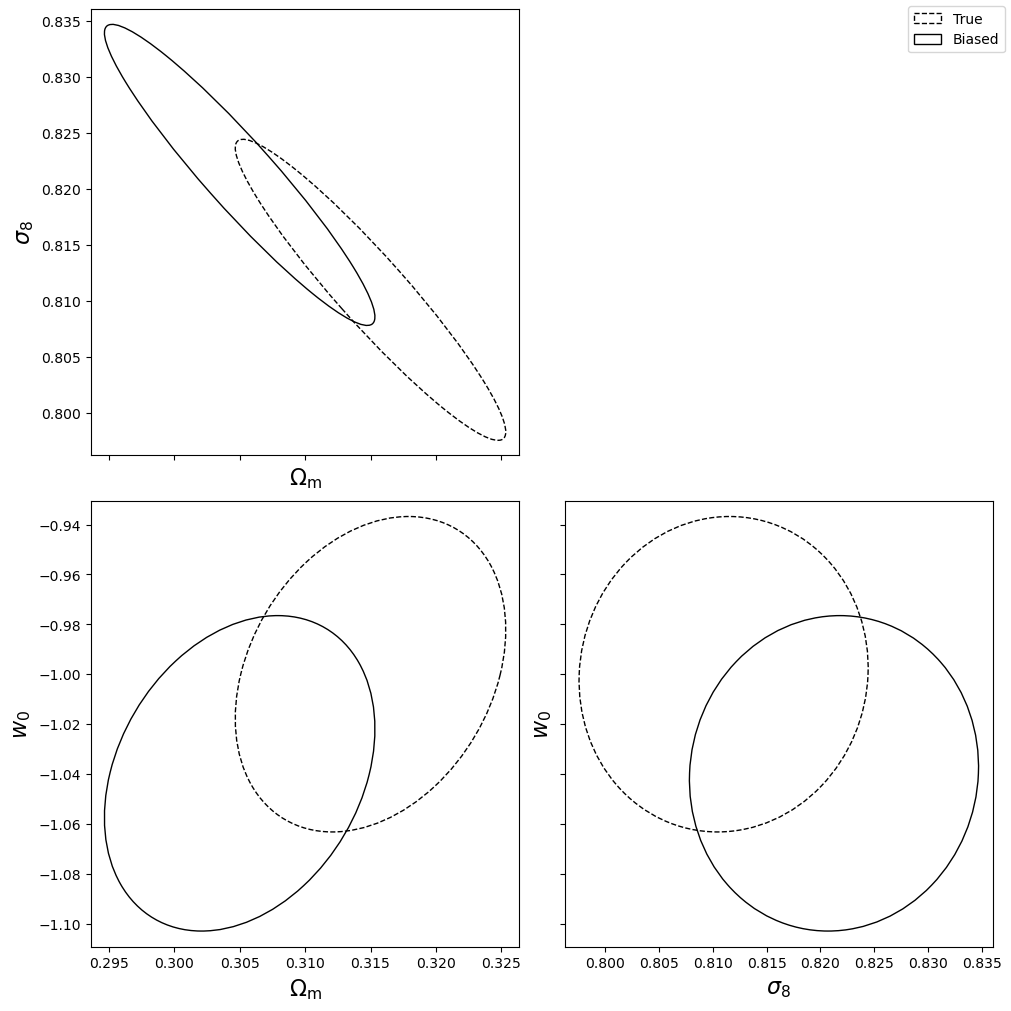

In [13]:
parameters = fm_no_AIA.parameters
fig, axes = plt.subplots(len(parameters)-1, len(parameters)-1, figsize=(10,10),
                         sharex='col', sharey='row', layout='compressed', squeeze=False)
for p2i, param2 in enumerate(parameters[1:]): # row
    for p1i, param1 in enumerate(parameters[:-1]): # column
        ax = axes[p2i, p1i]
        if p1i>p2i:
            fig.delaxes(ax)
            continue
        else:
            ax, xlim, ylim, mu, latex = fm.draw_covariance_ellipse(ax, [param1, param2],
                CL=0.68, color='k', fill=False, ls='--', label='True')
            ax, xlim_b, ylim_b, mu_b, latex_b = fm.draw_covariance_ellipse(ax, [param1, param2],
                                                                           mu=(biased_centers[p1i], biased_centers[p2i+1]),
                                                                           CL=0.68, color='k', fill=False, ls='-', label='Biased')

            ax.set_xlim([min(mu[0]-1.1*xlim, mu_b[0]-1.1*xlim_b), max(mu[0]+1.1*xlim, mu_b[0]+1.1*xlim_b)])
            ax.set_ylim([min(mu[1]-1.1*ylim, mu_b[1]-1.1*ylim_b), max(mu[1]+1.1*ylim, mu_b[1]+1.1*ylim_b)])

            ax.set_xlabel(f'{latex[0]}', fontsize=16)
            ax.set_ylabel(f'{latex[1]}', fontsize=16)
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels)